In [1]:
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from sklearn.metrics import accuracy_score


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "components").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "components").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))



from components.models import ANFISAdvanced, init_mf_params


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ---------------------------
# 1) Prepare make_circles data
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HAS_CUDA = torch.cuda.is_available()
if HAS_CUDA:
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def build_circles(n_samples=2000, noise=0.05):
    X, y = make_circles(n_samples=n_samples, factor=0.4, noise=noise, random_state=SEED)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)
    return X_scaled, y.astype(np.int64)


X, y = build_circles()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

/home/nazanin/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
# ---------------------------
# 5) Training loop
# ---------------------------
device = torch.device("cuda" if HAS_CUDA else "cpu")

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

K = 2
init_method = "random_uniform"  # choose: "fcm", "random_uniform"
centers_init, spreads_init = init_mf_params(X_train, K, method=init_method, scale=1.0)

s_mode_choice = "alpha_beta"
model = ANFISAdvanced(centers_init, spreads_init, s_mode=s_mode_choice).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 1200
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 200 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_prob = torch.sigmoid(model(X_train_tensor))
            test_prob = torch.sigmoid(model(X_test_tensor))
            train_rmse = torch.sqrt(torch.mean((train_prob - y_train_tensor) ** 2)).item()
            test_rmse = torch.sqrt(torch.mean((test_prob - y_test_tensor) ** 2)).item()
        print(
            f"Epoch {epoch:04d}/{n_epochs}  Loss {loss.item():.4f}  "
        )

if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    final_train_logits = model(X_train_tensor)
    final_test_logits = model(X_test_tensor)
    final_train_prob = torch.sigmoid(final_train_logits).cpu().numpy().reshape(-1)
    final_test_prob = torch.sigmoid(final_test_logits).cpu().numpy().reshape(-1)

    # MF internals (return_parts=True for blend info)
    w, mu_g, mu_s, blend, mu_blend = model.mf_layer(X_test_tensor, return_parts=True)

train_pred = (final_train_prob > 0.5).astype(int)
test_pred = (final_test_prob > 0.5).astype(int)
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("\nFinal Results:")
print(f"Train RMSE: {1-train_acc:.4f}  |  Train Acc: {train_acc:.3f}")
print(f"Test  RMSE: {1-test_acc:.4f}  |  Test  Acc: {test_acc:.3f}")


def summarize_split(name, y_true, pred, accuracy_rate):
    total = len(y_true)
    correct = int((pred == y_true).sum())
    wrong = total - correct
    error_rate = 1.0 - accuracy_rate
    print(
        f"{name}: accuracy rate {accuracy_rate:.3f} ({correct}/{total} correct dots) | "
        f"error {error_rate:.3f} ({wrong} wrong dots)"
    )


print("\nDot-level classification summary:")
summarize_split("Train", y_train, train_pred, train_acc)
summarize_split("Test", y_test, test_pred, test_acc)


# ---------------------------
# MF participation / contributions
# ---------------------------
# Contribution = blend * MF value (actual influence)
gauss_contrib = (blend * mu_g).mean(dim=0).cpu().numpy()  # per-rule, per-feature
sig_contrib = ((1 - blend) * mu_s).mean(dim=0).cpu().numpy()

# Raw participation (weights sum to 1)
gauss_weight = blend.mean(dim=0).cpu().numpy()
sig_weight = (1 - blend).mean(dim=0).cpu().numpy()

n_rules, n_features = gauss_contrib.shape

print("\nPer-rule, per-feature MF contributions and raw participation:")
for r in range(n_rules):
    for f in range(n_features):
        print(f"Rule {r}, Feature {f}: "
              f"Raw weight -> Gaussian={gauss_weight[r,f]:.4f}, Sigmoid={sig_weight[r,f]:.4f}")


Epoch 0001/1200  Loss 0.7007  
Epoch 0200/1200  Loss 0.6380  
Epoch 0400/1200  Loss 0.5370  
Epoch 0600/1200  Loss 0.4201  
Epoch 0800/1200  Loss 0.3368  
Epoch 1000/1200  Loss 0.2826  
Epoch 1200/1200  Loss 0.2429  

Final Results:
Train RMSE: 0.0121  |  Train Acc: 0.988
Test  RMSE: 0.0167  |  Test  Acc: 0.983

Dot-level classification summary:
Train: accuracy rate 0.988 (1383/1400 correct dots) | error 0.012 (17 wrong dots)
Test: accuracy rate 0.983 (590/600 correct dots) | error 0.017 (10 wrong dots)

Per-rule, per-feature MF contributions and raw participation:
Rule 0, Feature 0: Raw weight -> Gaussian=0.1935, Sigmoid=0.8065
Rule 0, Feature 1: Raw weight -> Gaussian=0.9659, Sigmoid=0.0341
Rule 1, Feature 0: Raw weight -> Gaussian=1.0000, Sigmoid=0.0000
Rule 1, Feature 1: Raw weight -> Gaussian=1.0000, Sigmoid=0.0000


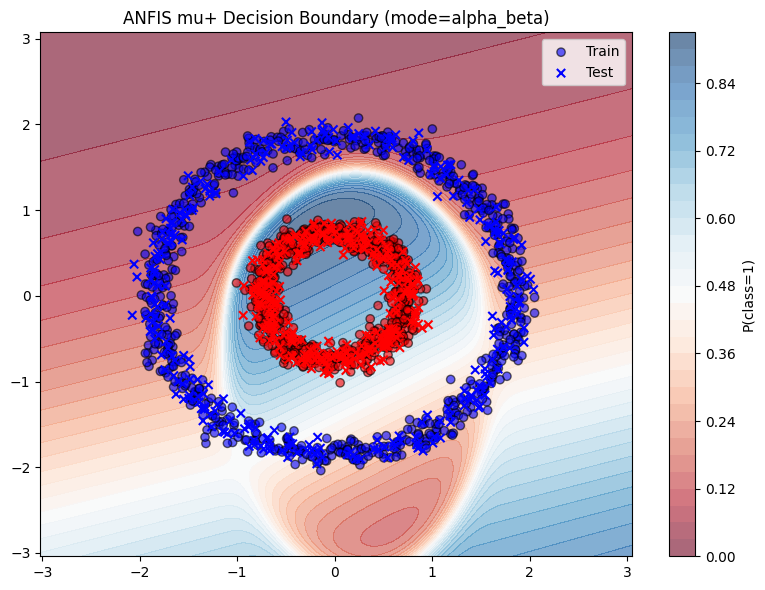

In [4]:
# ---------------------------
# 6) Decision boundary visualization
# ---------------------------
xx, yy = np.meshgrid(
    np.linspace(X_train[:, 0].min() - 1.0, X_train[:, 0].max() + 1.0, 250),
    np.linspace(X_train[:, 1].min() - 1.0, X_train[:, 1].max() + 1.0, 250),
)
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_tensor = torch.from_numpy(grid).to(device)
with torch.no_grad():
    grid_prob = torch.sigmoid(model(grid_tensor)).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, grid_prob, levels=30, cmap="RdBu", alpha=0.6)
plt.colorbar(label="P(class=1)")
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap="bwr",
    edgecolor="k",
    alpha=0.6,
    label="Train",
)
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="bwr",
    marker="x",
    label="Test",
)
plt.title(f"ANFIS mu+ Decision Boundary (mode={s_mode_choice})")
plt.legend()
plt.tight_layout()
plt.show()



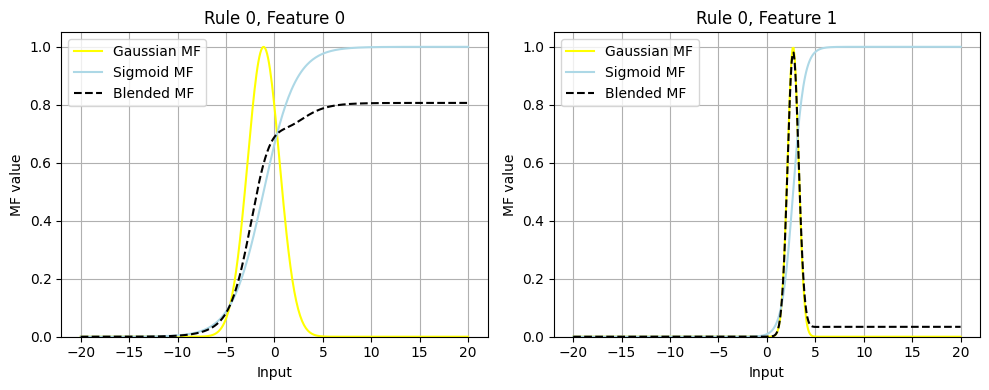

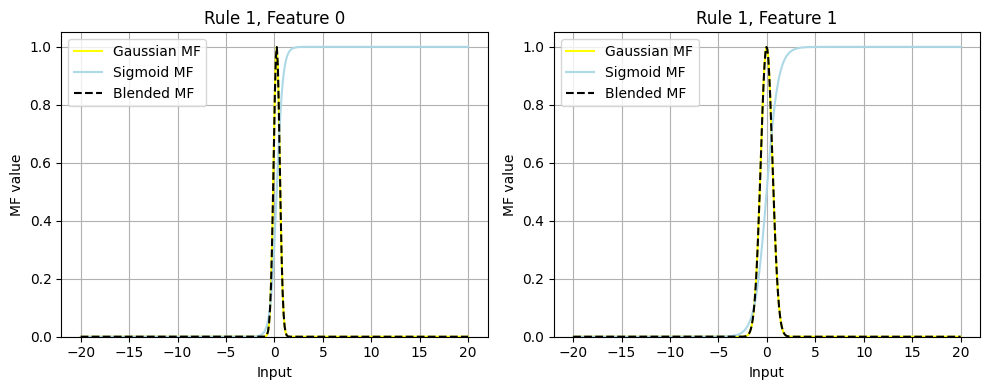

In [5]:
def plot_mfs_rule(model, rule, x_range=(-20, 20), n=400):
    """Plot Gaussian, Sigmoid, and blended MFs for all features of one rule in a single row."""
    
    n_features = model.n_inputs
    x = np.linspace(*x_range, n, dtype=np.float32)
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(next(model.parameters()).device)
    
    with torch.no_grad():
        w, mu_gauss, mu_sig, blend, mu_blend = model.mf_layer(x_tensor, return_parts=True)

    fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 4))
    if n_features == 1:
        axes = [axes]  # ensure axes is iterable
    
    for f, ax in enumerate(axes):
        mu_g = mu_gauss[:, rule, f].cpu().numpy()
        mu_s = mu_sig[:, rule, f].cpu().numpy()
        mu_b = mu_blend[:, rule, f].cpu().numpy()

        ax.plot(x, mu_g, label='Gaussian MF', color='yellow')
        ax.plot(x, mu_s, label='Sigmoid MF', color='lightblue')
        ax.plot(x, mu_b, '--', label='Blended MF', color='black')
        ax.set_title(f"Rule {rule}, Feature {f}")
        ax.set_xlabel("Input")
        ax.set_ylabel("MF value")
        ax.set_ylim(0, 1.05)
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

# Example usage: plot all features of each rule
for r in range(model.K):
    plot_mfs_rule(model, r)
